# Single map + single model -> attribution heatmap

The canonical exploration loop: **load one map, run the model of your choice,
see the query-driven attribution heatmap.** Edit the **CONFIG** cell, run top to
bottom.

**Two attribution methods (`METHOD`):**
- `"lrp"` -- **dynamicLRP** (the real method). Works for **`siglip2_base`**
  (SigLIP-2 base: split-free pooling head + fp32 relevance, fits the L4) and
  **`vit_b16`**. This is the one to use for SigLIP-2.
- `"ig"` -- captum **Integrated Gradients** baseline. Model-agnostic; use for the
  models LRP can't run here: **`siglip2`** (so400m -- fp32 LRP exceeds 22 GB),
  **`clip`** (op-coverage gap), **`paligemma`** (OOMs). No engine hacks.

Pairing: **`siglip2_base` / `vit_b16` -> `"lrp"`; `siglip2` / `clip` / `paligemma` -> `"ig"`.**

**The heatmap** is **pixel-level** (per-pixel relevance, not coarse patch blocks)
and percentile-normalized so outliers don't wash it out. Tune in the last cell:
`PIXEL_LEVEL` (pixel vs blocks) and `PCT` (lower = denser).

**Hardware (hard constraint):** single NVIDIA L4, ~22.5 GB. One model in VRAM at
a time (the load cell frees the previous). SigLIP-2 so400m fp32 LRP exceeds 22 GB
(use `siglip2_base` for LRP, or `siglip2`+`"ig"`); the IG baseline fits any model.

**Canonical example:** `MAP_INDEX = 444` -- a 1636 Tassin map of the Champagne
region, France.

In [39]:
# ====================== CONFIG -- edit me ======================
MODEL_NAME = "siglip2_base"  # "siglip2_base" | "vit_b16" | "siglip2" | "clip" | "paligemma"
MAP_INDEX  = 150             # Rumsey manifest index (444 = canonical 1636 Tassin
                             # map of the Champagne region, France)
QUERY      = "A river"       # free-text query (text-conditioned models); vit_b16
QUERIES    = [
    "Are there large in-line borders?",
    "Which way is north?",
    "Are there any rivers on the map?",
    "Does the map depict any mountains?",
    "Does the map depict any trees or forests?",
]
                             # maps it to an ImageNet class (no text tower)
METHOD     = "lrp"           # "lrp" -> siglip2_base, vit_b16 (dynamicLRP)
                             # "ig"  -> siglip2, clip, paligemma (Integrated Grads)
# ===============================================================
print("config:", MODEL_NAME, "| map", MAP_INDEX, "| query", repr(QUERY),
      "| method", METHOD)

config: siglip2_base | map 150 | query 'A river' | method lrp


In [32]:
# Setup: path wiring, imports, device + vendored-engine integrity check.
import sys, gc
from pathlib import Path

_REPO_ROOT = Path.cwd()
if not (_REPO_ROOT / "notebooks").exists() and _REPO_ROOT.name == "notebooks":
    _REPO_ROOT = _REPO_ROOT.parent
for _p in (_REPO_ROOT / "third_party" / "dynamicLRP" / "src", _REPO_ROOT / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import torch
import matplotlib.pyplot as plt
from mapclass import config

assert torch.cuda.is_available(), "CUDA required -- run on the GPU VM (CLAUDE.md)."
_sha = (_REPO_ROOT / "third_party" / "dynamicLRP" / "VENDOR_SHA").read_text().strip()
assert config.VENDOR_SHA == _sha, "vendored dynamicLRP SHA drift -- do not proceed"

def vram_gb():
    return torch.cuda.memory_allocated() / 1024**3

print("device :", torch.cuda.get_device_name(0),
      f"| {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB total")
print("VRAM in use :", f"{vram_gb():.2f} GB")

device : NVIDIA L4 | 22.0 GB total
VRAM in use : 5.66 GB


map id : RUMSEY~8~1~290517~90067288
index  : 150  (of 1544)
size   : (1536, 1291)


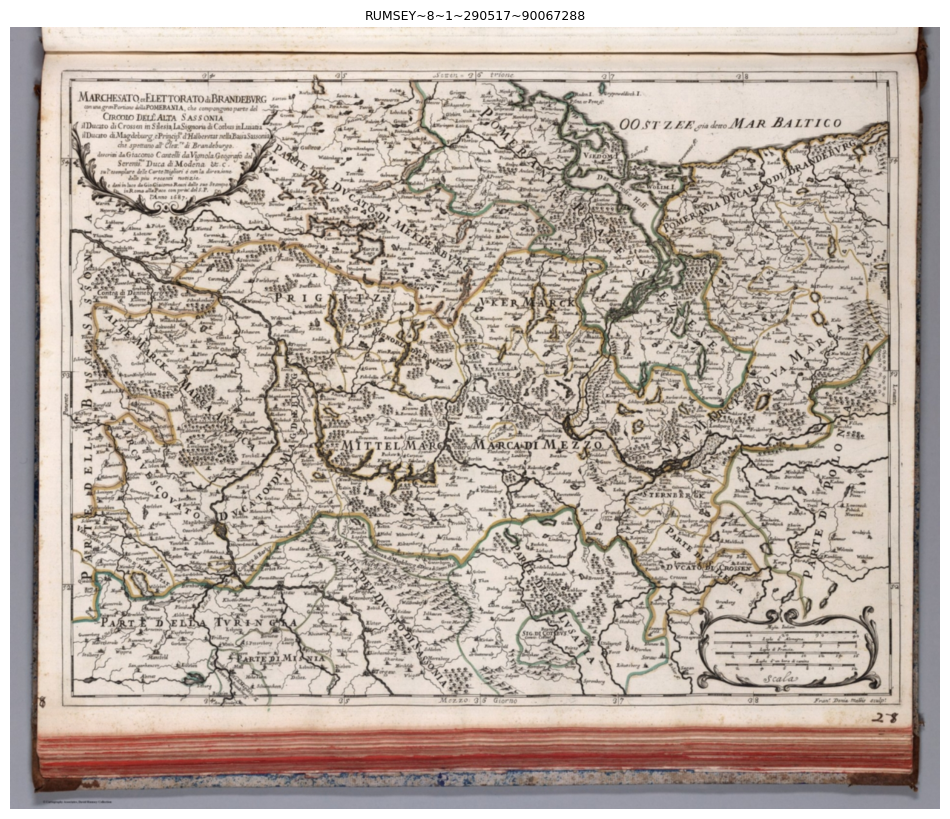

In [33]:
# Step 1 -- load the image.
from PIL import Image
from mapclass.manifest import load_manifest, entry_by_index
from mapclass.data_loader import _cached_image_path

manifest = load_manifest()
entry = entry_by_index(manifest, MAP_INDEX)
pil = Image.open(_cached_image_path(entry["id"])).convert("RGB")
print(f"map id : {entry['id']}")
print(f"index  : {MAP_INDEX}  (of {len(manifest)})")
print(f"size   : {pil.size}")

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(pil); ax.set_axis_off(); ax.set_title(entry["id"], fontsize=9)
plt.show()

In [34]:
# Step 2 -- load the model of your choice. Frees a previously-loaded model first
# so only ONE model is ever resident in VRAM (L4 hard constraint).
from mapclass.models import MODEL_REGISTRY

assert MODEL_NAME in MODEL_REGISTRY, (
    f"unknown model {MODEL_NAME!r}; choose from {list(MODEL_REGISTRY)}"
)

# Free a model left over from a previous run of this cell, if any.
try:
    model.to("cpu"); del model, processor          # noqa: F821
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

spec = MODEL_REGISTRY[MODEL_NAME]
geom = spec["patch_geom"]
model, processor = spec["load_fn"]()
try:
    model._mapclass_processor = processor          # PaliGemma target_fn needs it
except Exception:
    pass
print(f"loaded {MODEL_NAME!r} | patch_geom {geom} | VRAM now {vram_gb():.2f} GB")

loaded 'siglip2_base' | patch_geom {'patch_size': 16, 'img_dim': 224, 'has_cls': False} | VRAM now 6.33 GB


In [35]:
# Run the chosen attribution for (this image, this model). A coverage gap or OOM
# is caught and reported as "no heatmap" -- never a crash.
from mapclass import overlay as ovl

if METHOD == "lrp":
    from mapclass.attribution import attribute as _attr_fn        # dynamicLRP
elif METHOD == "ig":
    from mapclass.attribution_ig import attribute_ig as _attr_fn  # captum IG
else:
    raise ValueError(f"METHOD must be 'lrp' or 'ig', got {METHOD!r}")

forward_inputs, img_tensor = spec["build_inputs_fn"](
    model, processor, pil, QUERY, config.DEVICE
)
forward_inputs_for_fwd = {k: v for k, v in forward_inputs.items()
                          if not k.startswith("_")}
forward_inputs["_query"] = QUERY        # ViT class-target reads this

result, fail = None, None
try:
    result = _attr_fn(
        model, forward_inputs_for_fwd, img_tensor,
        lambda mdl, out, _fi, _f=spec["target_fn"]: _f(mdl, out, forward_inputs),
    )
    print(f"OK [{METHOD}]  target_form={result.target_form}  "
          f"similarity={result.similarity:.4f}  "
          f"peak_vram={(result.peak_vram_bytes or 0)/1024**3:.2f} GB")
except Exception as e:
    fail = f"{type(e).__name__}: {str(e)[:200]}"
    print(f"NO HEATMAP [{METHOD}] --", fail)

OK [lrp]  target_form=slice_2d  similarity=0.1003  peak_vram=6.89 GB


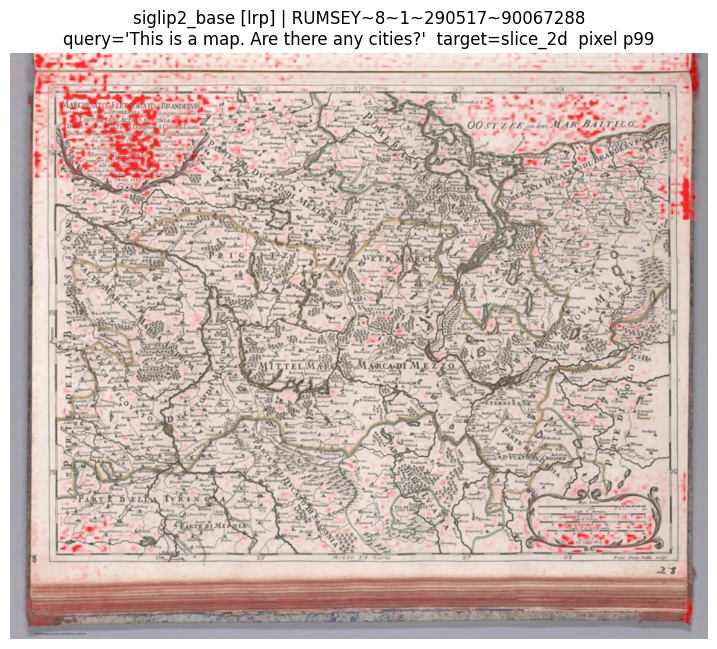

In [36]:
# Step 3 -- see it. Pixel-level signed (D-09) overlay (per-pixel relevance, NOT
# coarse patch blocks), zero-centered and percentile-normalized so a few outlier
# pixels don't wash the rest out to white.
PIXEL_LEVEL = True       # True = per-pixel heatmap; False = coarse patch blocks
PCT         = 99.0       # color/alpha scale = this percentile of |relevance|
                         # (lower it, e.g. 95, for a denser overlay)

fig, ax = plt.subplots(figsize=(9, 9))
if result is not None:
    if PIXEL_LEVEL:
        gs, gm = ovl.to_pixel_grid(result.relevance, has_cls=geom["has_cls"])
        interp = "bilinear"
    else:
        gs, gm = ovl.to_patch_grid(
            result.relevance, patch_size=geom["patch_size"],
            img_dim=geom["img_dim"], has_cls=geom["has_cls"],
        )
        interp = "nearest"
    ovl.composite(
        ax, pil, gs, gm,
        title=f"{MODEL_NAME} [{METHOD}] | {entry['id']}\n"
              f"query={QUERY!r}  target={result.target_form}  "
              f"{'pixel' if PIXEL_LEVEL else 'patch'} p{PCT:g}",
        interpolation=interp, pct=PCT,
    )
else:
    w, h = pil.size
    ax.imshow(pil, extent=(0, w, h, 0))
    ax.text(0.5, 0.5, f"no heatmap\n{MODEL_NAME} [{METHOD}]\n{fail}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color="white",
            bbox=dict(boxstyle="round", facecolor="black", alpha=0.7), wrap=True)
    ax.set_axis_off()
plt.show()

OK [lrp]  target_form=slice_2d  similarity=0.0484  peak_vram=15.32 GB


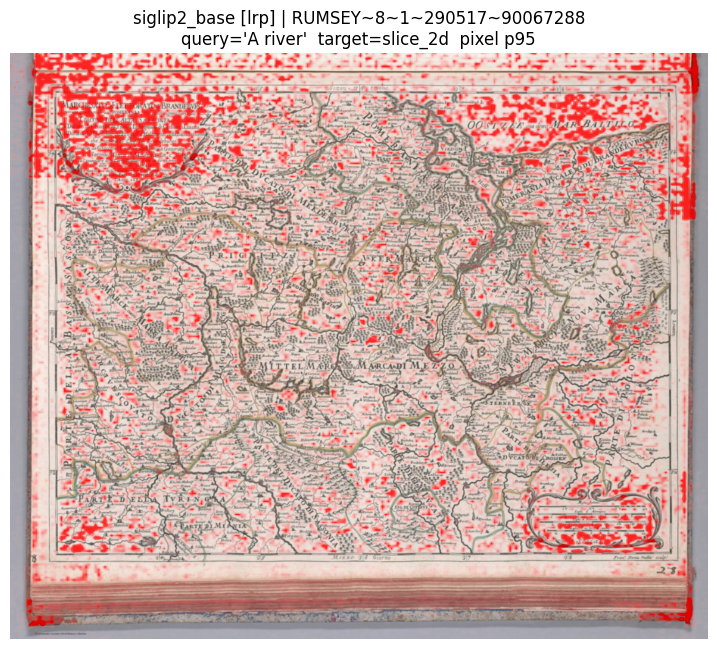

OK [lrp]  target_form=slice_2d  similarity=0.0484  peak_vram=15.88 GB


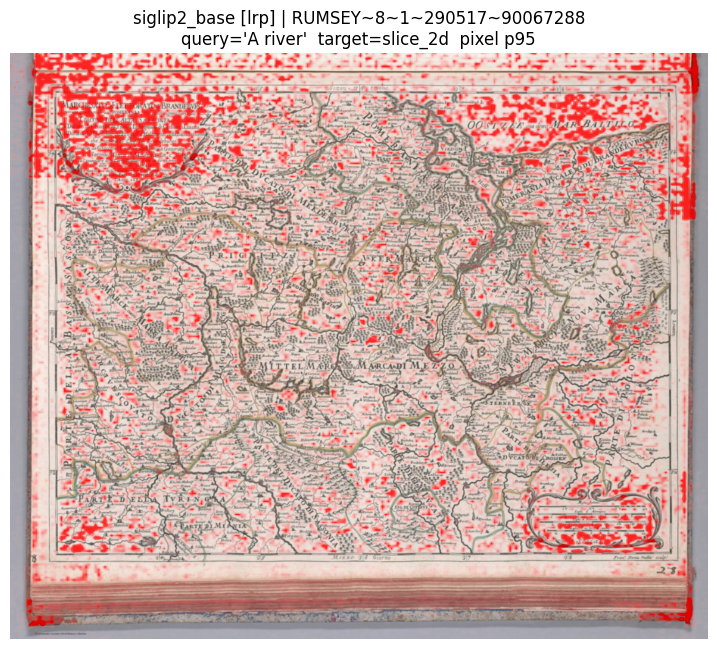

OK [lrp]  target_form=slice_2d  similarity=0.0484  peak_vram=16.44 GB


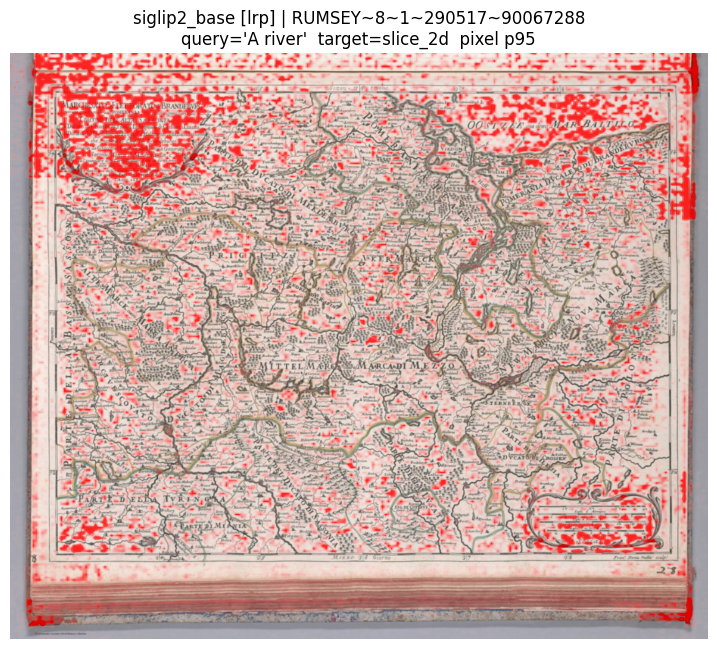

OK [lrp]  target_form=slice_2d  similarity=0.0484  peak_vram=17.01 GB


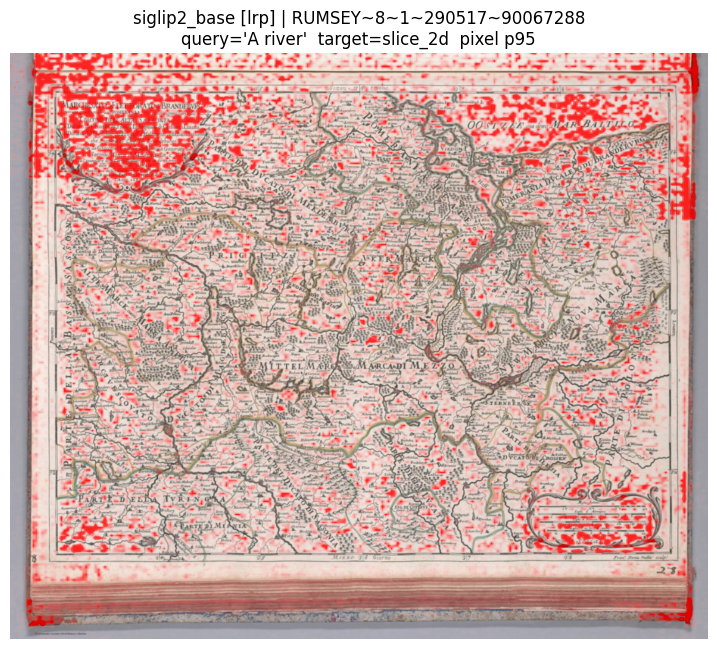

OK [lrp]  target_form=slice_2d  similarity=0.0484  peak_vram=17.57 GB


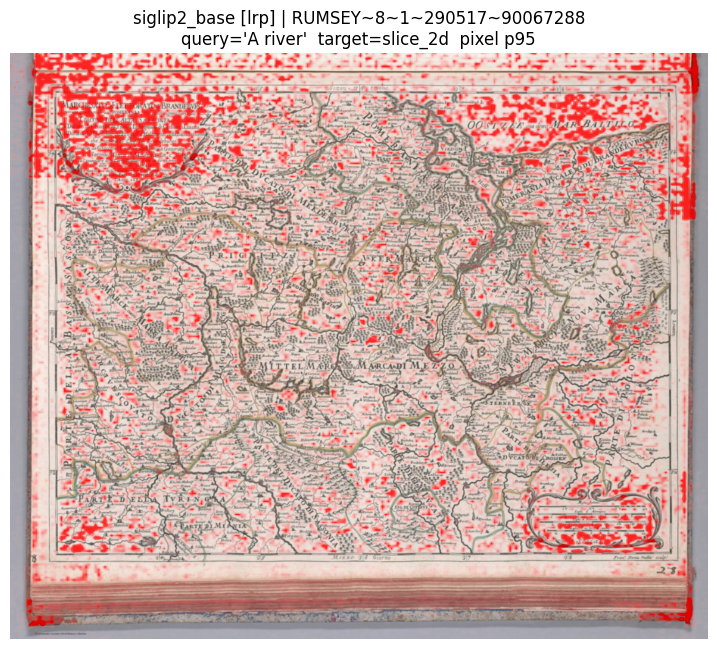

In [46]:
# Step 4 - Look at multiple outputs side-by-side
from mapclass.attribution import attribute as _attr_fn        # dynamicLRP

def query_image(query, pct=95):
    PIXEL_LEVEL = True       # True = per-pixel heatmap; False = coarse patch blocks
    PCT         = pct       # color/alpha scale = this percentile of |relevance|
                             # (lower it, e.g. 95, for a denser overlay)
    forward_inputs, img_tensor = spec["build_inputs_fn"](
        model, processor, pil, QUERY, config.DEVICE
    )
    forward_inputs_for_fwd = {k: v for k, v in forward_inputs.items()
                              if not k.startswith("_")}
    forward_inputs["_query"] = query        # ViT class-target reads this
    
    result, fail = None, None
    try:
        result = _attr_fn(
            model, forward_inputs_for_fwd, img_tensor,
            lambda mdl, out, _fi, _f=spec["target_fn"]: _f(mdl, out, forward_inputs),
        )
        print(f"OK [{METHOD}]  target_form={result.target_form}  "
              f"similarity={result.similarity:.4f}  "
              f"peak_vram={(result.peak_vram_bytes or 0)/1024**3:.2f} GB")
    except Exception as e:
        fail = f"{type(e).__name__}: {str(e)[:200]}"
        print(f"NO HEATMAP [{METHOD}] --", fail)    
    
    fig, ax = plt.subplots(figsize=(9, 9))
    if result is not None:
        if PIXEL_LEVEL:
            gs, gm = ovl.to_pixel_grid(result.relevance, has_cls=geom["has_cls"])
            interp = "bilinear"
        else:
            gs, gm = ovl.to_patch_grid(
                result.relevance, patch_size=geom["patch_size"],
                img_dim=geom["img_dim"], has_cls=geom["has_cls"],
            )
            interp = "nearest"
        ovl.composite(
            ax, pil, gs, gm,
            title=f"{MODEL_NAME} [{METHOD}] | {entry['id']}\n"
                  f"query={QUERY!r}  target={result.target_form}  "
                  f"{'pixel' if PIXEL_LEVEL else 'patch'} p{PCT:g}",
            interpolation=interp, pct=PCT,
        )
    else:
        w, h = pil.size
        ax.imshow(pil, extent=(0, w, h, 0))
        ax.text(0.5, 0.5, f"no heatmap\n{MODEL_NAME} [{METHOD}]\n{fail}",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=9, color="white",
                bbox=dict(boxstyle="round", facecolor="black", alpha=0.7), wrap=True)
        ax.set_axis_off()
    plt.show()

for i in QUERIES:
    query_image(i, 95)